In [1]:
# %% [code]
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt


In [3]:
# %% [code]
def load_txt_dataset(directory):
    """
    Scans subfolders 'healthy' and 'sick' within the provided directory and returns lists of file paths and corresponding labels.
    healthy  -> label 0
    sick     -> label 1
    """
    filepaths = []
    labels = []
    for label, class_name in enumerate(['healthy', 'sick']):
        class_dir = os.path.join(directory, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith('.txt'):
                filepaths.append(os.path.join(class_dir, fname))
                labels.append(label)
    return filepaths, labels
        


In [4]:

class TxtDataSequence(Sequence):
    def __init__(self, filepaths, labels, batch_size=32, target_size=(224,224), shuffle=True):
        self.filepaths = filepaths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index+1) * self.batch_size, len(self.filepaths))
        batch_indices = self.indices[start:end]
        X = []
        batch_labels = []
        for i in batch_indices:
            f = self.filepaths[i]
            try:
                # Read the first line to detect delimiter
                with open(f, "r") as file:
                    first_line = file.readline().strip()
                    delimiter = ";" if ";" in first_line else None
                img = np.loadtxt(f, delimiter=delimiter)
            except Exception as e:
                print(f"Error reading {f}: {e}")
                continue
            # Ensure image has a channel dimension
            if img.ndim == 2:
                img = np.expand_dims(img, axis=-1)
            # Convert grayscale to 3-channel if needed
            if img.shape[-1] == 1:
                img = np.concatenate([img, img, img], axis=-1)
            # Resize image to target size
            img_resized = cv2.resize(img, self.target_size)
            # Convert to float and normalize pixel values to [0, 255] if needed
            img_resized = img_resized.astype('float32')
            # Use the ResNet50 preprocess_input function
            img_resized = preprocess_input(img_resized)
            X.append(img_resized)
            batch_labels.append(self.labels[i])
        if not X:
            # In case all files in a batch fail, return empty arrays.
            return np.empty((0, *self.target_size, 3)), np.empty((0, 2))
        X = np.array(X)
        y = to_categorical(np.array(batch_labels), num_classes=2)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [5]:
# %% [code]
# Define the dataset directory (adjust the path as needed)
dataset_dir = os.path.join('datasets', 'original(txt)')

# Load file paths and labels
filepaths, labels = load_txt_dataset(dataset_dir)
total_samples = len(filepaths)
print("Total samples:", total_samples)

# Split dataset: 80% training, 20% test (using stratification)
train_filepaths, test_filepaths, train_labels, test_labels = train_test_split(
    filepaths, labels, test_size=0.2, random_state=42, stratify=labels
)
print("Training samples:", len(train_filepaths))
print("Test samples:", len(test_filepaths))

# Visualize class distribution in training set
print("Training class distribution:", Counter(train_labels))


Total samples: 265
Training samples: 212
Test samples: 53
Training class distribution: Counter({0: 138, 1: 74})


In [6]:
# %% [code]
batch_size = 32

train_sequence = TxtDataSequence(train_filepaths, train_labels, batch_size=batch_size, target_size=(224,224), shuffle=True)
test_sequence  = TxtDataSequence(test_filepaths, test_labels, batch_size=batch_size, target_size=(224,224), shuffle=False)

steps_per_epoch_train = len(train_sequence)
steps_per_epoch_test  = len(test_sequence)
print("Steps per epoch (train):", steps_per_epoch_train)
print("Steps per epoch (test):", steps_per_epoch_test)


Steps per epoch (train): 7
Steps per epoch (test): 2


In [7]:
# %% [code]
# Define input shape
input_shape = (224, 224, 3)

# Create base model from prebuilt ResNet50 (include_top=False to remove the default classification head)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

# Freeze base model layers initially (optional, for fine-tuning later you might unfreeze some layers)
for layer in base_model.layers:
    layer.trainable = False
# Add new classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(2, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
# %% [code]
# Compile the model with an appropriate loss and optimizer
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Optionally, set up class weights (if needed) based on training class distribution
total_train = len(train_labels)
weight_for_0 = total_train / (2 * train_labels.count(0))
weight_for_1 = total_train / (2 * train_labels.count(1))
class_weights = {0: weight_for_0, 1: weight_for_1}
print("Class weights:", class_weights)

# Train the model
epochs = 6
history = model.fit(
    train_sequence,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch_train,
    class_weight=class_weights,
    verbose=1,
    validation_data=test_sequence,
    validation_steps=steps_per_epoch_test
)

Class weights: {0: 0.7681159420289855, 1: 1.4324324324324325}
Epoch 1/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.9114 - loss: 0.2201 - val_accuracy: 0.8302 - val_loss: 0.3902
Epoch 2/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8770 - loss: 0.2410 - val_accuracy: 0.8679 - val_loss: 0.3037
Epoch 3/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.8881 - loss: 0.3188 - val_accuracy: 0.8113 - val_loss: 0.3558
Epoch 4/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9327 - loss: 0.1996 - val_accuracy: 0.8868 - val_loss: 0.3112
Epoch 5/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9398 - loss: 0.2047 - val_accuracy: 0.8302 - val_loss: 0.3549
Epoch 6/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8881 - loss: 0.1846 - val_accuracy: 0.8868 - val_loss: 0.3273


In [9]:
# %% [code]
eval_loss, eval_accuracy = model.evaluate(test_sequence, steps=steps_per_epoch_test, verbose=1)
print(f"Test Loss: {eval_loss:.4f}")
print(f"Test Accuracy: {eval_accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.8599 - loss: 0.2963
Test Loss: 0.2993
Test Accuracy: 0.8679


In [10]:
# %% [code]
predictions = []
true_labels_arr = []

# Iterate over the test sequence batches to collect predictions
for X_batch, y_batch in test_sequence:
    # Skip empty batches if any
    if X_batch.size == 0:
        break
    preds = model.predict(X_batch)
    predictions.extend(np.argmax(preds, axis=1))
    true_labels_arr.extend(np.argmax(y_batch, axis=1))

if len(true_labels_arr) == 0:
    raise ValueError("No test samples were processed. Check your data generator.")

# Trim predictions and labels to the exact number of test samples
predictions = np.array(predictions)[:len(test_filepaths)]
true_labels_arr = np.array(true_labels_arr)[:len(test_filepaths)]

# Compute confusion matrix
cm = confusion_matrix(true_labels_arr, predictions)
print("Confusion Matrix:\n", cm)

# Compute sensitivity and specificity if confusion matrix is 2x2
if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"Sensitivity (TPR): {sensitivity:.4f}")
    print(f"Specificity (TNR): {specificity:.4f}")
else:
    print("Confusion matrix dimensions unexpected for binary classification.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Confusion Matrix:
 [[30  4]
 [ 3 16]]
Sensitivity (TPR): 0.8421
Specificity (TNR): 0.8824


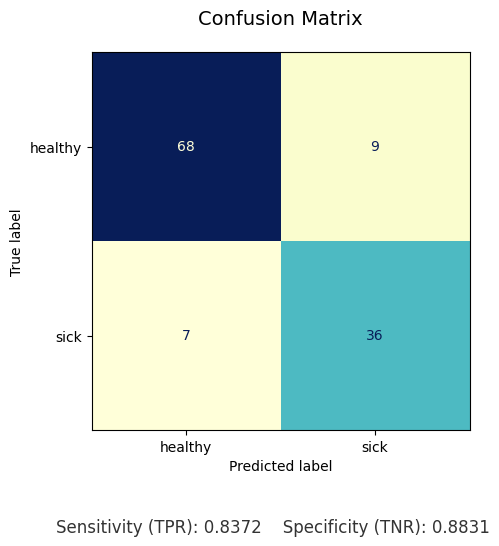

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1) Your confusion matrix
cm = np.array([[68, 9],
               [ 7,36]])


# 2) Compute sensitivity & specificity
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# 3) Plot
labels = ['healthy','sick']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='YlGnBu', colorbar=False)
ax.set_title('Confusion Matrix', pad=20, fontsize=14)

# Adjust spacing to leave room at bottom for the text
plt.subplots_adjust(bottom=0.25)

# 4) Annotate below
plt.figtext(0.5, 0.08,
            f"Sensitivity (TPR): {sensitivity:.4f}    Specificity (TNR): {specificity:.4f}",
            ha='center', fontsize=12, color='#333333')

plt.show()


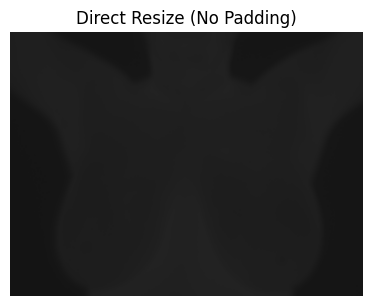

In [17]:
def visualize_resize(image, target_size=(224,224)):
    """
    Returns two versions of the resized image:
      1. Directly resized to target_size (which may distort the aspect ratio)
      2. Resized with padding (preserving aspect ratio)
    """
    # Direct resizing without padding (may distort image)
    # direct_resized = cv2.resize(image, target_size)
    
    # Resizing with padding using the previously defined function
    
    return image

# Example usage:
# Let's pick an image from your dataset. For this example, we'll load one txt file.
example_file = filepaths[0]  # change index if needed
try:
    with open(example_file, "r") as file:
        first_line = file.readline().strip()
        delimiter = ";" if ";" in first_line else None
    example_img = np.loadtxt(example_file, delimiter=delimiter)
except Exception as e:
    print(f"Error reading {example_file}: {e}")

# Ensure image has 3 channels (if grayscale, convert by replicating the channel)
if example_img.ndim == 2:
    example_img = np.expand_dims(example_img, axis=-1)
if example_img.shape[-1] == 1:
    example_img = np.concatenate([example_img, example_img, example_img], axis=-1)

# Obtain both resized versions
direct_resized= visualize_resize(example_img, target_size=(224,224))

# Plot both images side by side
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title("Direct Resize (No Padding)")
plt.imshow(direct_resized.astype(np.uint8))  # convert to uint8 if necessary
plt.axis('off')
plt.show()


In [16]:

import pandas as pd

# Create a new data sequence for all images with shuffle disabled 
# (to preserve the order of filepaths and labels as loaded)
all_sequence = TxtDataSequence(filepaths, labels, batch_size=32, target_size=(224,224), shuffle=False)

# Generate predictions for all images (265 in your case)
predictions = model.predict(all_sequence, verbose=1)

# Convert softmax output to predicted labels (0 for 'healthy', 1 for 'sick')
predicted_labels = np.argmax(predictions, axis=1)

# Build a DataFrame with Filename, Actual label, and Predicted label
df_results = pd.DataFrame({
    'Filename': filepaths,     # filepaths list as loaded by load_txt_dataset()
    'Actual': labels,          # actual labels (0 or 1)
    'Predicted': predicted_labels  # predicted labels from the model
})

# Optionally, map numeric labels to their class names for readability
label_mapping = {0: 'healthy', 1: 'sick'}
df_results['Actual_Class'] = df_results['Actual'].map(label_mapping)
df_results['Predicted_Class'] = df_results['Predicted'].map(label_mapping)

# Display the table
print(df_results)
# %% [code]
# Save the entire list of predictions to a text file
with open("predictions.txt", "w") as f:
    f.write(df_results.to_string(index=False))

print("Predictions saved to predictions.txt")


c:\Users\2004a\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
                                              Filename  Actual  Predicted  \
0    datasets\original(txt)\healthy\T0001.1.1.S.201...       0          0   
1    datasets\original(txt)\healthy\T0002.1.1.S.201...       0          1   
2    datasets\original(txt)\healthy\T0004.1.1.S.201...       0          0   
3    datasets\original(txt)\healthy\T0005.1.1.S.201...       0          0   
4    datasets\original(txt)\healthy\T0006.1.1.S.201...       0          1   
..                                                 ...     ...        ...   
260  datasets\original(txt)\sick\T0415.1.1.S.2019-0...       1          1   
261  datasets\original(txt)\sick\T0418.1.1.S.2020-0...       1          1   
262  datasets\original(txt)\sick\T0422.1.1.S.2019-0...       1          1   
263  datasets\original(txt)\sick\T0424.1.1.S.2019-0...       1          1   
264  datasets\original(txt)\sick\T0425.1.1.S.2020-0...       1          1   

    Actual_Class Predicted_Class  
0  